# Ablation IMV - MAGIC Gamma / tabular feature groups

Feature-group ablation on the public
[UCI MAGIC Gamma Telescope dataset](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope)
([DOI 10.24432/C52C8B](https://doi.org/10.24432/C52C8B)), scored with the
installed `imvpy` package. The dataset is CC BY 4.0 licensed and contains 19,020
simulated telescope events, ten continuous image measurements, no missing
values, and a binary gamma-versus-hadron target.

This example keeps one MLP architecture fixed and removes one physically
related predictor group at a time. That isolates the information contributed
by geometry, concentration, moments, and orientation without mixing feature
removal with model-family changes.

**Pipeline**: download the checksum-validated UCI data -> make leakage-free
stratified splits -> train the full and four ablated models over ten seeds ->
calculate and visualise directional ablation IMV.

This is an example run, not a replication of a published result. The UCI
dataset description cautions that the simulated class balance is not
representative of operation in the field, so ROC AUC and balanced accuracy are
reported only as familiar diagnostics; IMV itself is calculated from the
held-out probabilistic predictions. Downloaded data, restartable predictions,
and exported artifacts are cached outside the repository under `~/.cache/imv`.


In [1]:
import gc
import hashlib
import os
import shutil
import sys
import tempfile
import time
import warnings
from pathlib import Path
from types import SimpleNamespace
from urllib.request import urlretrieve
from zipfile import ZipFile


_PATH_DISPLAY_ROOT = Path()


def relative_path(path, *, start=None):
    '''Return a display-only path relative to an explicit local anchor.'''

    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(
            Path(path).expanduser().resolve(), start=anchor.expanduser().resolve()
        )
    except ValueError:
        relative = Path(path).name
    return Path(relative).as_posix()


def _relative_warning_text(message):
    text = str(message)
    roots = {
        Path.home(),
        Path(sys.prefix),
        Path(sys.base_prefix),
        _PATH_DISPLAY_ROOT,
        Path(tempfile.gettempdir()),
    }
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text


def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(
        f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}",
        file=stream,
    )


warnings.showwarning = _show_relative_warning


%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from joblib import Parallel, delayed, parallel_config
from tqdm.auto import tqdm

import imvpy
from imvpy import AblationIMV, information_deficit, ll
from imvpy.utils import plot_ablation_matrix, save_figure


IMVPY_SOURCE = Path(imvpy.__file__).resolve().parent


CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "uci_magic_gamma"
ARTIFACTS = Path(
    os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")
) / "ablation_imv_magic_gamma"
RESULTS = ARTIFACTS / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "requirements.txt").is_file() and (path / "src").is_dir()),
    Path.cwd(),
)
FIGURES = Path(os.environ.get(
    "IMV_FIGURE_DIR", PROJECT_ROOT / "output" / "figures"
))
FIGURES.mkdir(parents=True, exist_ok=True)
PREDICTIONS = RESULTS / "feature_groups_mlp64x32_e12_v1"
PREDICTIONS.mkdir(parents=True, exist_ok=True)
FORCE_RECOMPUTE = os.environ.get("IMV_FORCE_RECOMPUTE", "0").strip().lower() in {
    "1", "true", "yes",
}


SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
BATCH, TEST_BATCH, EPOCHS, LR = 256, 1024, 12, 1e-3
CPU_COUNT = (len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity")
             else (os.cpu_count() or 1))
TORCH_THREADS = min(4, CPU_COUNT)
torch.set_num_threads(TORCH_THREADS)


ablator = AblationIMV(random_seed=SEEDS[0])
DEFAULT_TORCH_JOBS = min(6, max(1, CPU_COUNT // TORCH_THREADS), len(SEEDS))
REQUESTED_TORCH_JOBS = int(os.environ.get("IMV_TORCH_JOBS", DEFAULT_TORCH_JOBS))
if REQUESTED_TORCH_JOBS < 1:
    raise ValueError("IMV_TORCH_JOBS must be a positive integer")
TORCH_N_JOBS = (min(REQUESTED_TORCH_JOBS, len(SEEDS),
                    max(1, CPU_COUNT // TORCH_THREADS))
                if ablator.device.type == "cpu" else 1)
print(f"imvpy {imvpy.__version__} from {relative_path(IMVPY_SOURCE)}")
print("package class:", f"{AblationIMV.__module__}.{AblationIMV.__name__}")
print(f"device: {ablator.device}; seed workers: {TORCH_N_JOBS}; "
      f"PyTorch threads per worker: {TORCH_THREADS}")


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
imvpy 1.2.0 from ../../../../../../../../anaconda3/lib/python3.12/site-packages/imvpy
package class: imvpy.ablation_imv.evaluator.AblationIMV
device: cpu; seed workers: 6; PyTorch threads per worker: 4


## 1. Download and validate

The notebook downloads the 646 KB archive directly from UCI and validates the
SHA-256 digest of `magic04.data` before parsing it. No data is committed to the
repository. The ten predictor names and group definitions follow the UCI data
dictionary.


In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/159/magic+gamma+telescope.zip"
DATA_SHA256 = "e9314b7ebd4b4b59a3b3d65f7316663963777b16a46786877651dbbaa640b36a"
DATA_MEMBER = "magic04.data"


def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def ensure_magic_data():
    DATA_HOME.mkdir(parents=True, exist_ok=True)
    data_path = DATA_HOME / DATA_MEMBER
    if data_path.exists() and file_sha256(data_path) == DATA_SHA256:
        return data_path

    archive_path = DATA_HOME / "magic_gamma_telescope.zip.download"
    extracted_path = DATA_HOME / f"{DATA_MEMBER}.download"
    try:
        urlretrieve(DATA_URL, archive_path)
        with ZipFile(archive_path) as archive:
            if DATA_MEMBER not in archive.namelist():
                raise RuntimeError(f"UCI archive does not contain {DATA_MEMBER}")
            with archive.open(DATA_MEMBER) as source, extracted_path.open("wb") as target:
                shutil.copyfileobj(source, target)
        actual = file_sha256(extracted_path)
        if actual != DATA_SHA256:
            raise RuntimeError(
                f"Checksum mismatch for {DATA_MEMBER}: expected {DATA_SHA256}, got {actual}"
            )
        extracted_path.replace(data_path)
    finally:
        archive_path.unlink(missing_ok=True)
        extracted_path.unlink(missing_ok=True)
    return data_path


FEATURES = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
]
data_path = ensure_magic_data()
data = pd.read_csv(data_path, header=None, names=[*FEATURES, "class"])

if data.shape != (19020, 11):
    raise RuntimeError(f"Expected 19,020 rows and 11 columns, got {data.shape}")
if set(data["class"]) != {"g", "h"}:
    raise RuntimeError(f"Unexpected target labels: {sorted(data['class'].unique())}")
data[FEATURES] = data[FEATURES].apply(pd.to_numeric, errors="raise")
if data[FEATURES].isna().any().any():
    raise RuntimeError("Unexpected missing predictor values in MAGIC Gamma data")
data["target"] = (data.pop("class") == "g").astype("int64")

print("source:", relative_path(data_path))
print(data.shape, "class counts:", data["target"].value_counts().sort_index().to_dict())
data.head()


source: ../../../../../../../../.cache/imv/datasets/uci_magic_gamma/magic04.data
(19020, 11) class counts: {0: 6688, 1: 12332}


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,target
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


## 2. Define the feature-group ablations

The four groups partition all ten predictors. Every variant uses the same
train/test rows, train-fitted scaler, optimisation budget, and 64-by-32 MLP;
only the named input group is omitted.


In [3]:
VARIANT_DROPS = {
    "FullFeatures": [],
    "NoGeometry": ["fLength", "fWidth"],
    "NoConcentration": ["fSize", "fConc", "fConc1"],
    "NoMoments": ["fAsym", "fM3Long", "fM3Trans"],
    "NoOrientation": ["fAlpha", "fDist"],
}
VARIANTS = list(VARIANT_DROPS)


def kept_features(variant):
    dropped = set(VARIANT_DROPS[variant])
    return [feature for feature in FEATURES if feature not in dropped]


class TabularDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {"features": self.features[index], "labels": self.labels[index]}


def make_split(seed):
    train_frame, test_frame = train_test_split(
        data,
        test_size=0.25,
        stratify=data["target"],
        random_state=seed,
    )
    scaler = StandardScaler()
    train_scaled = pd.DataFrame(
        scaler.fit_transform(train_frame[FEATURES]),
        columns=FEATURES,
        index=train_frame.index,
    )
    test_scaled = pd.DataFrame(
        scaler.transform(test_frame[FEATURES]),
        columns=FEATURES,
        index=test_frame.index,
    )
    return (
        train_scaled,
        test_scaled,
        train_frame["target"].to_numpy(),
        test_frame["target"].to_numpy(),
    )


class GammaMLP(nn.Module):
    '''One fixed architecture used with each retained predictor set.'''

    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Linear(32, 2),
        )

    def forward(self, features, labels=None):
        logits = self.network(features)
        loss = None if labels is None else F.cross_entropy(logits, labels)
        return SimpleNamespace(loss=loss, logits=logits)


variant_rows = []
for variant in VARIANTS:
    retained = kept_features(variant)
    model = GammaMLP(len(retained))
    variant_rows.append(
        {
            "variant": variant,
            "omitted": ", ".join(VARIANT_DROPS[variant]) or "none",
            "retained_features": len(retained),
            "parameters": sum(parameter.numel() for parameter in model.parameters()),
        }
    )
variant_table = pd.DataFrame(variant_rows).set_index("variant")
variant_table


,omitted,retained_features,parameters
variant,,,
FullFeatures,none,10,3042
NoGeometry,"fLength, fWidth",8,2914
NoConcentration,"fSize, fConc, fConc1",7,2850
NoMoments,"fAsym, fM3Long, fM3Trans",7,2850
NoOrientation,"fAlpha, fDist",8,2914


## 3. Train and predict with the package

For each seed, all five prediction frames refer to exactly the same held-out
rows and labels. A fresh stratified split measures sensitivity to sampling as
well as optimisation. Standardisation is fitted on the training rows only.

Predictions are cached by run specification, and cached files are reused only
after their schema, probabilities, labels, and class decisions pass validation.

On CPU, complete seeds run in isolated processes; accelerator execution remains single-process to avoid device contention.

In [4]:
def prediction_path(variant, seed):
    return PREDICTIONS / f"predictions_magic_gamma_{variant.lower()}_seed_{seed}.csv"


def valid_cached_predictions(path, expected_labels):
    if not path.exists():
        return None
    try:
        frame = pd.read_csv(path)
    except (OSError, ValueError, pd.errors.ParserError):
        return None
    required = [
        "Negative Probability",
        "Positive Probability",
        "True Label",
        "Predicted Label",
    ]
    if list(frame.columns) != required or len(frame) != len(expected_labels):
        return None
    positive = frame["Positive Probability"].to_numpy(float)
    negative = frame["Negative Probability"].to_numpy(float)
    labels = frame["True Label"].to_numpy(int)
    predicted = frame["Predicted Label"].to_numpy(int)
    probabilities = np.column_stack([negative, positive])
    if (
        not np.isfinite(probabilities).all()
        or np.any((probabilities < 0) | (probabilities > 1))
        or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)
        or not np.array_equal(labels, expected_labels)
        or not np.array_equal(predicted, probabilities.argmax(axis=1))
    ):
        return None
    return frame


def write_csv_atomic(frame, path):
    temporary = path.with_name(f".{path.name}.{os.getpid()}.tmp")
    try:
        frame.to_csv(temporary, index=False)
        os.replace(temporary, path)
    finally:
        temporary.unlink(missing_ok=True)


previous_path = RESULTS / "magic_gamma_variant_diagnostics.csv"
if previous_path.exists():
    previous = pd.read_csv(previous_path)
    previous_minutes = {
        (int(row.seed), row.variant): float(row.minutes)
        for row in previous.itertuples()
        if pd.notna(row.minutes)
    }
else:
    previous_minutes = {}


def summarize_seed(seed, frames, cached, elapsed_minutes):
    diagnostics = []
    for variant in VARIANTS:
        frame = frames[variant]
        y = frame["True Label"].to_numpy(int)
        p = frame["Positive Probability"].to_numpy(float)
        predicted = frame["Predicted Label"].to_numpy(int)
        likelihood = ll(y, p)
        diagnostics.append(
            {
                "seed": seed,
                "variant": variant,
                "geometric_mean_likelihood": likelihood,
                "information_deficit_nats": information_deficit(likelihood),
                "roc_auc": roc_auc_score(y, p),
                "balanced_accuracy": balanced_accuracy_score(y, predicted),
                "parameters": int(variant_table.loc[variant, "parameters"]),
                "minutes": elapsed_minutes[variant],
                "cached": cached[variant],
            }
        )

    # Use the package implementation rather than transcribing the IMV formula.
    matrix = AblationIMV.calculate_imv_matrix(frames)
    matrix_records = [
        {"seed": seed, "enhanced": enhanced, "basic": basic,
         "ablation_imv": matrix.loc[enhanced, basic]}
        for enhanced in VARIANTS for basic in VARIANTS
    ]
    return {"seed": seed, "matrix": matrix, "matrix_records": matrix_records,
            "diagnostics": diagnostics}


def evaluate_seed(seed):
    torch.set_num_threads(TORCH_THREADS)
    worker_ablator = AblationIMV(random_seed=seed)
    train_x, test_x, train_y, test_y = make_split(seed)
    frames, cached, elapsed_minutes = {}, {}, {}
    for variant in VARIANTS:
        retained = kept_features(variant)
        path = prediction_path(variant, seed)
        started = time.perf_counter()
        frame = (None if FORCE_RECOMPUTE
                 else valid_cached_predictions(path, test_y))
        cached[variant] = frame is not None
        if frame is None:
            worker_ablator.set_seed(seed)
            model = GammaMLP(len(retained))
            train_loader = DataLoader(
                TabularDataset(train_x[retained].to_numpy(), train_y),
                batch_size=BATCH,
                shuffle=True,
            )
            test_loader = DataLoader(
                TabularDataset(test_x[retained].to_numpy(), test_y),
                batch_size=TEST_BATCH,
                shuffle=False,
            )
            run = worker_ablator.train_and_evaluate(
                model,
                train_loader,
                test_loader,
                num_epochs=EPOCHS,
                lr=LR,
                optimizer_class=torch.optim.AdamW,
                seed=seed,
                verbose=False,
            )
            frame = run["test_predictions"]
            write_csv_atomic(frame, path)
            del run, model, train_loader, test_loader
            gc.collect()
            if worker_ablator.device.type == "cuda":
                torch.cuda.empty_cache()
            elif worker_ablator.device.type == "mps":
                torch.mps.empty_cache()
        frames[variant] = frame
        elapsed_minutes[variant] = (
            previous_minutes.get((seed, variant), float("nan"))
            if cached[variant] else (time.perf_counter() - started) / 60
        )
    return summarize_seed(seed, frames, cached, elapsed_minutes)


seed_results, pending = [], []
for seed in SEEDS:
    _, _, _, expected_test_y = make_split(seed)
    cached_frames = {
        variant: (None if FORCE_RECOMPUTE else valid_cached_predictions(
            prediction_path(variant, seed), expected_test_y
        ))
        for variant in VARIANTS
    }
    if all(frame is not None for frame in cached_frames.values()):
        cached = {variant: True for variant in VARIANTS}
        elapsed = {variant: previous_minutes.get((seed, variant), float("nan"))
                   for variant in VARIANTS}
        seed_results.append(summarize_seed(seed, cached_frames, cached, elapsed))
    else:
        pending.append(seed)

restored = len(seed_results)
mode = "fresh" if FORCE_RECOMPUTE else "resume"
print(f"{mode} mode; {restored}/{len(SEEDS)} seeds restored; running {len(pending)} "
      f"with {TORCH_N_JOBS} workers")
if pending:
    with parallel_config(backend="loky", inner_max_num_threads=TORCH_THREADS):
        stream = Parallel(
            n_jobs=TORCH_N_JOBS, return_as="generator_unordered", batch_size=1,
            pre_dispatch=TORCH_N_JOBS,
        )(delayed(evaluate_seed)(seed) for seed in pending)
        with tqdm(total=len(SEEDS), initial=restored, desc="MAGIC Gamma seeds",
                  unit="seed") as progress:
            for result in stream:
                seed_results.append(result)
                progress.set_postfix_str(f"seed {result['seed']}")
                progress.update()

if len(seed_results) != len(SEEDS):
    raise RuntimeError(f"expected {len(SEEDS)} seed results, found {len(seed_results)}")
seed_order = {seed: index for index, seed in enumerate(SEEDS)}
seed_results.sort(key=lambda result: seed_order[result["seed"]])

seed_matrices = [result["matrix"] for result in seed_results]
matrix_records = [row for result in seed_results for row in result["matrix_records"]]
diagnostics = [row for result in seed_results for row in result["diagnostics"]]
for result in seed_results:
    print(f"seed {result['seed']}")
    for row in result["diagnostics"]:
        note = "reused" if row["cached"] else f"{row['minutes']:.2f} min"
        print(f"  {row['variant']:<17} a={row['geometric_mean_likelihood']:.5f} "
              f"AUC={row['roc_auc']:.4f} ({note})")

diagnostic_frame = pd.DataFrame(diagnostics)
by_seed = pd.DataFrame(matrix_records)
write_csv_atomic(diagnostic_frame, RESULTS / "magic_gamma_variant_diagnostics.csv")
write_csv_atomic(by_seed, RESULTS / "magic_gamma_ablation_imv_by_seed.csv")
diagnostic_frame.groupby("variant")[[
    "geometric_mean_likelihood",
    "information_deficit_nats",
    "roc_auc",
    "balanced_accuracy",
]].agg(["mean", "std"])


fresh mode; 0/10 seeds restored; running 10 with 6 workers


MAGIC Gamma seeds:   0%|          | 0/10 [00:00<?, ?seed/s]

Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu
Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


Using device: CPU
Note: No GPU available, training will be slower
PyTorch version: 2.9.0+cpu


seed 42
  FullFeatures      a=0.73241 AUC=0.9257 (0.02 min)
  NoGeometry        a=0.70314 AUC=0.9073 (0.02 min)
  NoConcentration   a=0.69406 AUC=0.8985 (0.01 min)
  NoMoments         a=0.73733 AUC=0.9296 (0.01 min)
  NoOrientation     a=0.66307 AUC=0.8644 (0.01 min)
seed 43
  FullFeatures      a=0.73784 AUC=0.9329 (0.02 min)
  NoGeometry        a=0.70721 AUC=0.9110 (0.02 min)
  NoConcentration   a=0.68958 AUC=0.8960 (0.01 min)
  NoMoments         a=0.73596 AUC=0.9316 (0.01 min)
  NoOrientation     a=0.65311 AUC=0.8518 (0.01 min)
seed 44
  FullFeatures      a=0.73576 AUC=0.9265 (0.03 min)
  NoGeometry        a=0.70583 AUC=0.9087 (0.02 min)
  NoConcentration   a=0.69527 AUC=0.8980 (0.01 min)
  NoMoments         a=0.73698 AUC=0.9269 (0.02 min)
  NoOrientation     a=0.65448 AUC=0.8522 (0.03 min)
seed 45
  FullFeatures      a=0.73068 AUC=0.9258 (0.02 min)
  NoGeometry        a=0.69746 AUC=0.9034 (0.03 min)
  NoConcentration   a=0.68785 AUC=0.8966 (0.03 min)
  NoMoments         a=0.72673 AU

geometric_mean_likelihood           information_deficit_nats  \
                                     mean       std                     mean   
variant                                                                        
FullFeatures                     0.735192  0.005722                 0.385496   
NoConcentration                  0.692180  0.006098                 0.325204   
NoGeometry                       0.704003  0.004549                 0.342155   
NoMoments                        0.734796  0.004510                 0.384967   
NoOrientation                    0.656067  0.005685                 0.271620   

                            roc_auc           balanced_accuracy            
                      std      mean       std              mean       std  
variant                                                                    
FullFeatures     0.007769  0.928704  0.004033          0.838122  0.006560  
NoConcentration  0.008787  0.898366  0.004578          0.794074  0.010483  
NoGeometry       0.006465  0.908762  0.003601          0.814611  0.007832  
NoMoments        0.006147  0.928394  0.002879          0.838921  0.007696  
NoOrientation    0.008685  0.855528  0.005599          0.764307  0.009679

## 4. Directional ablation IMV

Rows are treated as the enhanced model and columns as the basic model.
Directional IMV is not constrained to be positive: a near-zero or negative
full-versus-ablation value is evidence that the omitted group did not add
held-out information under this model and training budget.

The standard deviation describes variation across the ten complete runs; it is
not a confidence interval.


In [5]:
mean_matrix = AblationIMV.average_imv_matrices(seed_matrices)
matrix_std = pd.DataFrame(
    np.std(
        np.stack([matrix.to_numpy() for matrix in seed_matrices]), axis=0, ddof=1
    ),
    index=mean_matrix.index,
    columns=mean_matrix.columns,
)
mean_matrix.to_csv(RESULTS / "magic_gamma_ablation_imv_directional.csv")
matrix_std.to_csv(RESULTS / "magic_gamma_ablation_imv_directional_std.csv")

print("Mean directional ablation IMV over", len(SEEDS), "seeds")
print("rows = enhanced model; columns = basic model")
mean_matrix


Mean directional ablation IMV over 10 seeds
rows = enhanced model; columns = basic model


,FullFeatures,NoGeometry,NoConcentration,NoMoments,NoOrientation
FullFeatures,0.000000,0.022442,0.032194,0.000244,0.067176
NoGeometry,-0.021946,0.000000,0.009539,-0.021711,0.043749
NoConcentration,-0.031179,-0.009439,0.000000,-0.030946,0.033889
NoMoments,-0.000239,0.022194,0.031943,0.000000,0.066913
NoOrientation,-0.062921,-0.041897,-0.032765,-0.062700,0.000000


## 5. Figures

The first figure shows all directional pairwise comparisons, using the same
heatmap convention as the MNIST and HAR ablation examples. The second isolates
the full model relative to each feature-group ablation. Error bars are one
standard deviation across seeds.


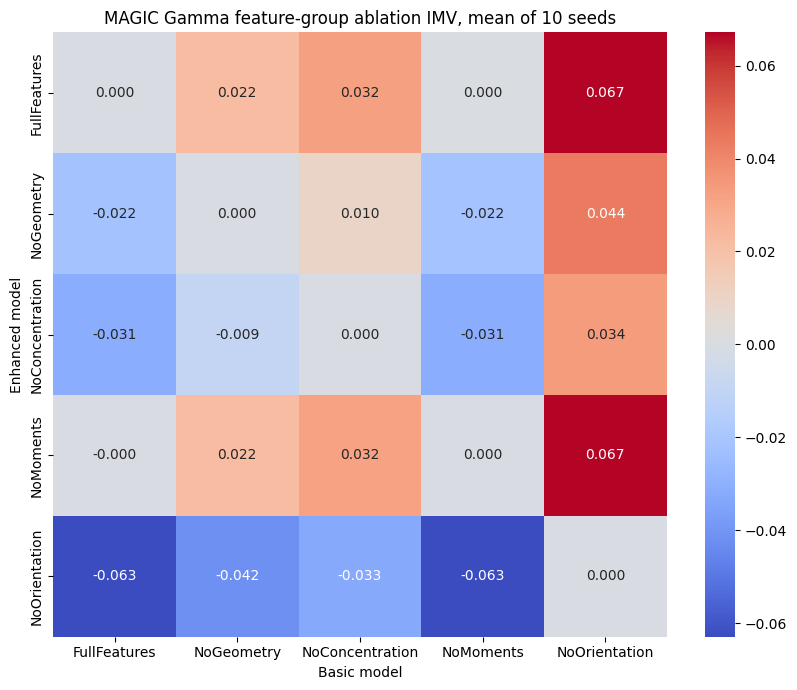

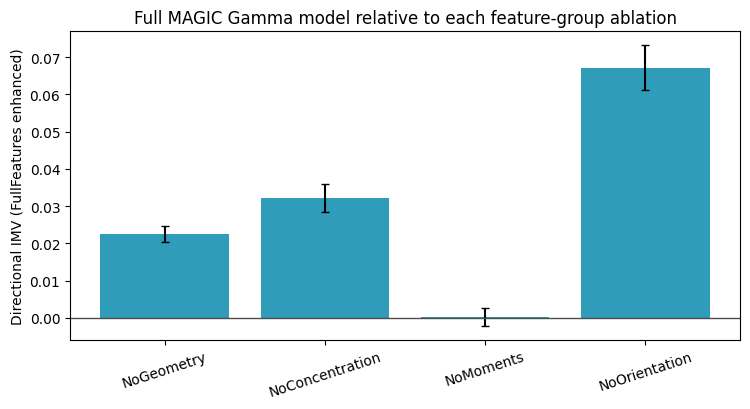

,mean,std
basic,,
NoGeometry,0.022442,0.002193
NoConcentration,0.032194,0.003657
NoMoments,0.000244,0.002379
NoOrientation,0.067176,0.006008


In [6]:
fig, ax = plot_ablation_matrix(
    mean_matrix,
    figsize=(8.4, 7.0),
    title=f"MAGIC Gamma feature-group ablation IMV, mean of {len(SEEDS)} seeds",
)
ax.set_xlabel("Basic model")
ax.set_ylabel("Enhanced model")
fig.tight_layout()
matrix_paths = {
    file_format: relative_path(path, start=ARTIFACTS)
    for file_format, path in save_figure(
        fig, FIGURES / "ablation_imv_magic_gamma__ablation_imv"
    ).items()
}
plt.show()


full_vs_ablation = (
    by_seed[
        (by_seed["enhanced"] == "FullFeatures")
        & (by_seed["basic"] != "FullFeatures")
    ]
    .groupby("basic", sort=False)["ablation_imv"]
    .agg(["mean", "std"])
    .reindex(VARIANTS[1:])
)
full_vs_ablation.to_csv(RESULTS / "magic_gamma_full_vs_ablation.csv")


fig2, ax2 = plt.subplots(figsize=(7.6, 4.2))
colors = [
    "#2f9cba" if value >= 0 else "#b4464b"
    for value in full_vs_ablation["mean"]
]
ax2.bar(
    full_vs_ablation.index,
    full_vs_ablation["mean"],
    yerr=full_vs_ablation["std"].fillna(0),
    capsize=3,
    color=colors,
)
ax2.axhline(0, color="0.3", linewidth=1)
ax2.set_ylabel("Directional IMV (FullFeatures enhanced)")
ax2.set_title("Full MAGIC Gamma model relative to each feature-group ablation")
ax2.tick_params(axis="x", rotation=18)
fig2.tight_layout()
comparison_paths = {
    file_format: relative_path(path, start=ARTIFACTS)
    for file_format, path in save_figure(
        fig2, FIGURES / "ablation_imv_magic_gamma__full_vs_ablation"
    ).items()
}
plt.show()
full_vs_ablation
